Fold 1/5 (Transformer)
APPLYING MIXUP AUGMENTATION...
Training Started...
Epoch 1/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.6101 - loss: 0.6213
Epoch 1: val_loss improved from None to 0.28118, saving model to results_Transformer_Mixup\best_model_fold1.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 105s 288ms/step - accuracy: 0.6666 - loss: 0.4670 - val_accuracy: 0.9593 - val_loss: 0.2812 - learning_rate: 1.0000e-04
Epoch 2/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7197 - loss: 0.3588
Epoch 2: val_loss improved from 0.28118 to 0.26817, saving model to results_Transformer_Mixup\best_model_fold1.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 98s 296ms/step - accuracy: 0.7198 - loss: 0.3508 - val_accuracy: 0.9681 - val_loss: 0.2682 - learning_rate: 1.0000e-04
Epoch 3/60
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7346 - loss: 0.3325
Epoch 3: val_loss improved from 0.26817 to 0.24866, saving model to results_Transformer_Mixup\best_model_fold1.keras
330/330 ━━━━━━━━━

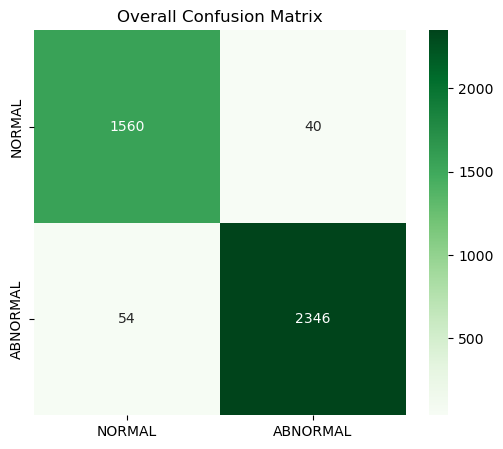

Overall Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.97      0.97      1600
    ABNORMAL       0.98      0.98      0.98      2400

    accuracy                           0.98      4000
   macro avg       0.97      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000


In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    BatchNormalization, GlobalAveragePooling1D, Reshape, Multiply, 
    SpatialDropout1D, Concatenate, Add, GlobalMaxPooling1D, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

PREPROCESSING_DIR = r"Preprocessing_Updated_Kfold"
N_FOLDS = 5
RESULTS_DIR = "results_Ictal_vs_All"
os.makedirs(RESULTS_DIR, exist_ok=True)

def mixup_batch(X, y, alpha=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    lam = np.random.beta(alpha, alpha, size=len(X)).astype(np.float32)
    
    if X.ndim == 2:
        lam_x = lam.reshape((len(X), 1))
    else:
        lam_x = lam.reshape((len(X), 1, 1))
    
    X_mix = X * lam_x + X[indices] * (1 - lam_x)
    
    y = np.array(y, dtype=np.float32)
    original_y_ndim = y.ndim
    y_reshaped = y.reshape((len(y), 1)) 
    lam_y = lam.reshape((len(X), 1))
    
    y_mix = y_reshaped * lam_y + y_reshaped[indices] * (1 - lam_y)
    
    if original_y_ndim == 1:
        y_mix = y_mix.flatten()
        
    return X_mix, y_mix

def augment_batch_advanced(X, y):
    X_aug, y_aug = [], []
    
    for i in range(len(X)):
        shift = np.random.randint(-5, 5)
        scale = np.random.uniform(0.97, 1.03)
        noise = np.random.normal(0, 0.005, X[i].shape).astype(np.float32)
        
        signal_mod = np.roll(X[i] + noise, shift) * scale
        
        X_aug.append(X[i])       
        y_aug.append(y[i])
        X_aug.append(signal_mod) 
        y_aug.append(y[i])
        
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.float32)
    
    X_mix, y_mix = mixup_batch(X_aug, y_aug)
    
    X_final = np.concatenate([X_aug, X_mix], axis=0)
    y_final = np.concatenate([y_aug, y_mix], axis=0)
    
    return X_final, y_final

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = Add()([x, inputs]) 

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Conv1D(ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(inputs.shape[-1], kernel_size=1)(x)
    x = Add()([x, res]) 
    return x

def inception_module(input_tensor, filters=32):
    conv1 = Conv1D(filters, kernel_size=3, padding='same', activation='relu')(input_tensor)
    conv2 = Conv1D(filters, kernel_size=5, padding='same', activation='relu')(input_tensor)
    conv3 = Conv1D(filters, kernel_size=11, padding='same', activation='relu')(input_tensor)
    pool = MaxPooling1D(3, strides=1, padding='same')(input_tensor)
    conv_pool = Conv1D(filters, kernel_size=1, padding='same', activation='relu')(pool)
    return Concatenate(axis=-1)([conv1, conv2, conv3, conv_pool])

def squeeze_excitation_block(input_tensor, ratio=4):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling1D()(input_tensor)
    excitation = Dense(channels // ratio, activation='relu')(squeeze)
    excitation = Dense(channels, activation='sigmoid')(excitation)
    excitation = Reshape((1, channels))(excitation)
    return Multiply()([input_tensor, excitation])

def build_inception_transformer(input_length):
    inputs = Input(shape=(input_length, 1))

    x = inception_module(inputs, filters=16)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.1)(x)

    x = inception_module(x, filters=32)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.15)(x)

    x = inception_module(x, filters=64)
    x = BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = MaxPooling1D(2)(x)
    x = SpatialDropout1D(0.2)(x)

    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
    
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="Inception_Transformer_IctalVsAll")
    
    model.compile(
        optimizer=Adam(1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

def predict_with_tta(model, X_test, iterations=4):
    preds = model.predict(X_test, verbose=0)
    for _ in range(iterations):
        X_aug = []
        for i in range(len(X_test)):
            shift = np.random.randint(-3, 3) 
            scale = np.random.uniform(0.98, 1.02)
            aug_sig = np.roll(X_test[i], shift) * scale
            X_aug.append(aug_sig)
        preds += model.predict(np.array(X_aug), verbose=0)
    return preds / (iterations + 1)

def plot_classification_report_heatmap(y_true, y_pred, title, save_path):
    report = classification_report(y_true, y_pred, target_names=['NON-SEIZURE', 'SEIZURE'], output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :].T
    plt.figure(figsize=(8, 5))
    sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.4f', cbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

acc_per_fold = []
conf_matrices = []
all_y_true = []
all_y_pred = []

for fold_no in range(N_FOLDS):
    print(f"\n{'='*60}\nFold {fold_no + 1}/{N_FOLDS} (Ictal vs All)\n{'='*60}")
    
    checkpoint_path = os.path.join(RESULTS_DIR, f"best_model_fold{fold_no + 1}.keras")

    X_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_train.npy"), allow_pickle=True).astype(np.float32)
    y_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_train.npy"), allow_pickle=True).astype(np.int32)
    X_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_test.npy"), allow_pickle=True).astype(np.float32)
    y_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_test.npy"), allow_pickle=True).astype(np.int32)
    
    ictal_label = np.max(y_train_full) 
    print(f"Detected Ictal Label ID: {ictal_label} (Setting this to 1, others to 0)")
    
    y_train_full_bin = np.where(y_train_full == ictal_label, 1, 0)
    y_test_bin = np.where(y_test == ictal_label, 1, 0)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full_bin, 
        test_size=0.1765, stratify=y_train_full_bin, random_state=42
    )

    print("APPLYING MIXUP AUGMENTATION...")
    X_train, y_train = augment_batch_advanced(X_train, y_train)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = build_inception_transformer(X_train.shape[1])
    
    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
    ]

    model.fit(X_train, y_train, epochs=60, batch_size=32, validation_data=(X_val, y_val), callbacks=callbacks, verbose=1)

    print(f"Loading best weights & Evaluating Fold {fold_no + 1}...")
    model.load_weights(checkpoint_path)
    
    y_probs = predict_with_tta(model, X_test)
    y_pred = (y_probs > 0.5).astype(int).flatten()
    
    acc = np.mean(y_pred == y_test_bin)
    print(f"Accuracy: {acc:.4f}")
    acc_per_fold.append(acc)
    
    all_y_true.extend(y_test_bin)
    all_y_pred.extend(y_pred)
    
    conf_matrices.append(confusion_matrix(y_test_bin, y_pred))
    
    plot_classification_report_heatmap(
        y_test_bin, y_pred, 
        f"Fold {fold_no + 1} Report", 
        os.path.join(RESULTS_DIR, f"report_fold{fold_no + 1}.png")
    )
    
    K.clear_session()
    gc.collect()

print(f"\nFINAL MEAN ACCURACY (ICTAL VS ALL): {np.mean(acc_per_fold):.4f} =+ {np.std(acc_per_fold):.4f}")

total_cm = np.sum(conf_matrices, axis=0)
plt.figure(figsize=(6, 5))
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NON-SEIZURE', 'SEIZURE'], yticklabels=['NON-SEIZURE', 'SEIZURE'])
plt.title("Overall Confusion Matrix")
plt.savefig(os.path.join(RESULTS_DIR, "overall_conf_matrix.png"))
plt.show()

print("\nOverall Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=['NON-SEIZURE', 'SEIZURE']))

plot_classification_report_heatmap(
    all_y_true, all_y_pred, 
    "Overall Consolidated Report", 
    os.path.join(RESULTS_DIR, "overall_classification_report.png")
)